In [ ]:
import json
import base64
import os
from PIL import Image
from io import BytesIO
from tqdm import tqdm

# =========================
# Paths
# =========================

WEBQA_JSON = "/scratch/shayan/Projects/mepa-attack/datasets/webqa-mmpoisionrag/WebQA_test_image.json"

IMGS_TSV = (
    "/scratch/shayan/Projects/mepa-attack/"
    "datasets/WebQA_data_first_release/WebQA_imgs_7z_chunks/imgs.tsv"
)

OUTPUT_DIR = (
    "/scratch/shayan/Projects/mepa-attack/"
    "datasets/webqa-mmpoisonrag/extracted_images"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

# =========================
# Step 1: Collect needed image IDs
# =========================

with open(WEBQA_JSON, "r") as f:
    webqa_data = json.load(f)

needed_image_ids = set()

for ex in webqa_data.values():
    for img in ex.get("img_posFacts", []):
        needed_image_ids.add(str(img["image_id"]))
    for img in ex.get("img_negFacts", []):
        needed_image_ids.add(str(img["image_id"]))

TOTAL = len(needed_image_ids)
print(f"Need to extract {TOTAL} unique images")

# =========================
# Step 2: Scan TSV and extract
# =========================

found = 0
remaining = set(needed_image_ids)

with open(IMGS_TSV, "r") as f, tqdm(
    total=TOTAL,
    desc="Extracted images",
    unit="img"
) as pbar:
    for line in f:
        if not remaining:
            break

        parts = line.rstrip("\n").split("\t")
        if len(parts) != 2:
            continue

        image_id, b64_data = parts

        if image_id not in remaining:
            continue

        out_path = os.path.join(OUTPUT_DIR, f"{image_id}.jpg")

        # Already extracted
        if os.path.exists(out_path):
            remaining.remove(image_id)
            found += 1
            pbar.update(1)
            continue

        try:
            image_bytes = base64.b64decode(b64_data)
            image = Image.open(BytesIO(image_bytes)).convert("RGB")
            image.save(out_path)

            remaining.remove(image_id)
            found += 1
            pbar.update(1)
        except Exception as e:
            print(f"Failed to extract image {image_id}: {e}")

# =========================
# Summary
# =========================

print("\n=== Extraction Summary ===")
print(f"Extracted images: {found}")
print(f"Missing images: {len(remaining)}")

if remaining:
    print("Missing image IDs (first 10):")
    for img_id in list(remaining)[:10]:
        print(" ", img_id)

print(f"\nImages saved to: {OUTPUT_DIR}")


Need to extract 38654 unique images


Extracted images: 100%|██████████| 38654/38654 [03:55<00:00, 164.18img/s]


=== Extraction Summary ===
Extracted images: 38654
Missing images: 0

Images saved to: /scratch/shayan/Projects/mepa-attack/datasets/webqa-mmpoisonrag/extracted_images


## The code above extracts all the required images from original WebQA data and stores it in another folder.

Loaded 2511 WebQA test examples

GUID: d5c7afd40dba11ecb1e81171463288e9
Question: What large architectural structure is seen at the Egyptian Pavilion in Expo Vancouver 86?
Gold answer(s): ['A building with with freestanding columns were at the Egyptian Pavilion in Expo Vancouver 86.']

--- Positive Evidence (1) ---

Image ID: 30349712
Caption: EGYPTIAN PAVILION AT EXPO 86, VANCOUVER, B.C. GREAT HALL OF RAMSES II WHO RULED FROM 1290-1224 B.C. FEATURES TREASURES FROM THE PERIOD OF HIS REIGN


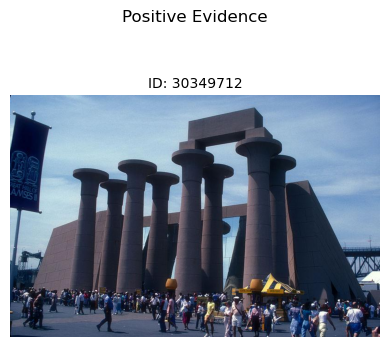


--- Negative Evidence (16) ---

Image ID: 30214110
Caption: Expo 86 - crowd

Image ID: 30122646
Caption: Expo 86 - monorail

Image ID: 30187853
Caption: "All the fun of the fair" - at Thorpe Park - geograph.org.uk - 860896 "All the fun of the fair" - at Thorpe Park

Image ID: 30286797
Caption: A Street Scene, City Centre Downtown, Vancouver during coronavirus pandemic (49924542443)

Image ID: 30012752
Caption: JAPANESE PAVILION AT EXPO 86, VANCOUVER, B.C. EXTERIOR FEATURES JAPANESE ARTWORK

Image ID: 30186042
Caption: NORWEGIAN PAVILION AT EXPO 86, VANCOUVER, B.C. NORWEGIAN PAVILION EMPHASIZES MARINE TECHNOLOGY WITH A MODEL OF ITS POLAR EXPLORATIONS

Image ID: 30134675
Caption: FRENCH PAVILION AT EXPO 86, VANCOUVER, B.C. FEATURES DECOR OF THE PARIS AIRPORT AND SHOWS THE TRAIN DE GRANDE VITESSE - FASTEST TRAIN IN THE WORLD WHICH TRAVELS AT 156 MPH

Image ID: 30036858
Caption: Harlem - Apollo Theater

Image ID: 30239668
Caption: Doric Temple of Athena Lindia Doric Temple of Athena Lindi

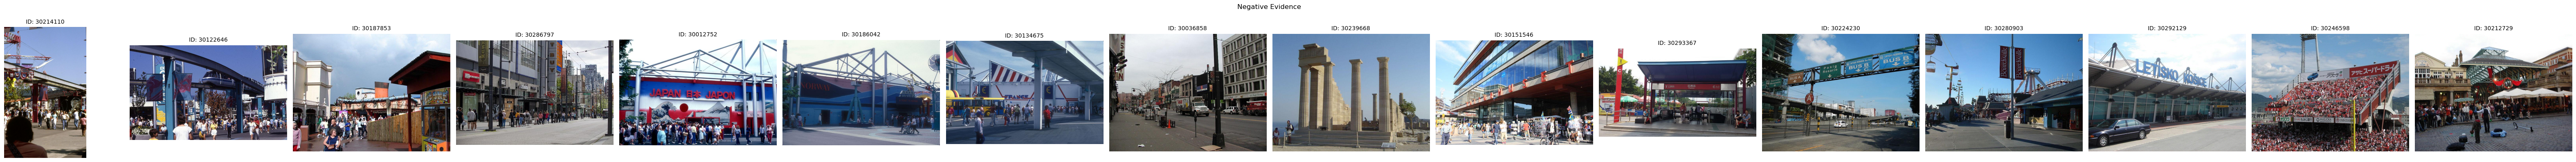

In [7]:
import json
import random
import os
from PIL import Image
import matplotlib.pyplot as plt

# =========================
# Paths
# =========================

WEBQA_JSON = "/scratch/shayan/Projects/mepa-attack/datasets/webqa-mmpoisionrag/WebQA_test_image.json"

EXTRACTED_IMAGE_DIR = (
    "/scratch/shayan/Projects/mepa-attack/"
    "datasets/webqa-mmpoisonrag/extracted_images"
)

# =========================
# Helper: load extracted image
# =========================

def load_webqa_image(image_id):
    path = os.path.join(EXTRACTED_IMAGE_DIR, f"{image_id}.jpg")
    return Image.open(path).convert("RGB")

# =========================
# Load WebQA data
# =========================

with open(WEBQA_JSON, "r") as f:
    webqa_data = json.load(f)

print(f"Loaded {len(webqa_data)} WebQA test examples")

# =========================
# Pick random example
# =========================

guid = random.choice(list(webqa_data.keys()))
ex = webqa_data[guid]

question = ex["Q"].strip('"')
gold_answers = [a.strip('"') for a in ex["A"]]

pos_images = ex.get("img_posFacts", [])
neg_images = ex.get("img_negFacts", [])

# =========================
# Print question + answers
# =========================

print("\n==============================")
print("GUID:", guid)
print("Question:", question)
print("Gold answer(s):", gold_answers)
print("==============================")

# =========================
# Display evidence
# =========================

def show_evidence(images, title):
    print(f"\n--- {title} ({len(images)}) ---")

    if not images:
        print("None")
        return

    fig, axes = plt.subplots(1, len(images), figsize=(4 * len(images), 4))
    if len(images) == 1:
        axes = [axes]

    for ax, img in zip(axes, images):
        img_id = img["image_id"]
        caption = img["caption"]

        try:
            image = load_webqa_image(img_id)
            ax.imshow(image)
            ax.axis("off")
            ax.set_title(f"ID: {img_id}", fontsize=10)
        except Exception as e:
            ax.text(0.5, 0.5, f"Missing image\n{img_id}", ha="center", va="center")
            ax.axis("off")

        print(f"\nImage ID: {img_id}")
        print("Caption:", caption)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# =========================
# Show positive & negative evidence
# =========================

show_evidence(pos_images, "Positive Evidence")
show_evidence(neg_images, "Negative Evidence")


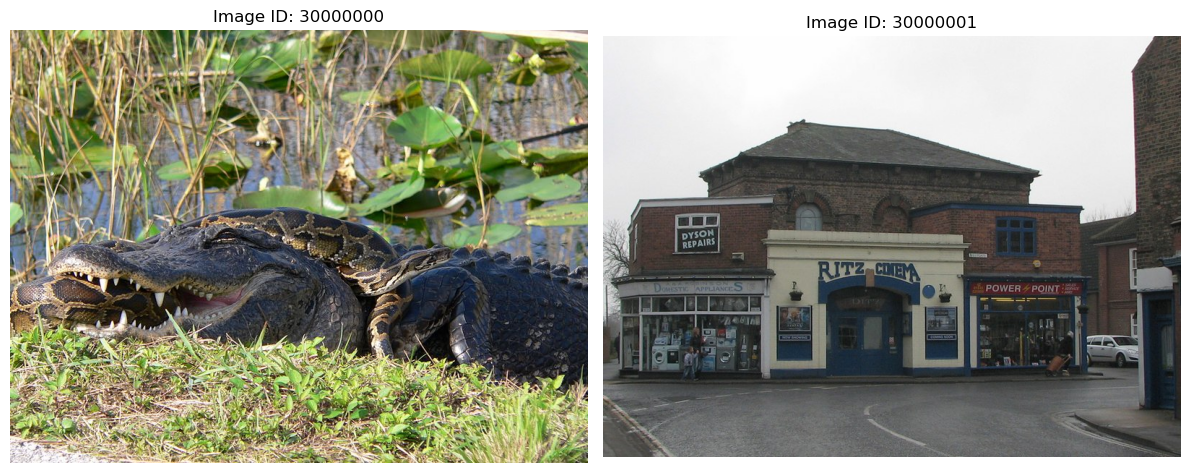

In [5]:
import base64
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

images_path = "/scratch/shayan/Projects/mepa-attack/datasets/WebQA_data_first_release/WebQA_imgs_7z_chunks/imgs.tsv"
# Read first two lines and display images
with open(images_path, 'r') as f:
    images = []
    image_ids = []
    
    for i, line in enumerate(f):
        if i >= 2:  # Stop after 2 lines
            break
            
        parts = line.strip().split('\t')
        if len(parts) >= 2:
            image_id = parts[0]
            base64_data = parts[1]
            
            # Decode base64 to image
            image_bytes = base64.b64decode(base64_data)
            image = Image.open(BytesIO(image_bytes))
            
            images.append(image)
            image_ids.append(image_id)
    
    # Display the images
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    for idx, (img, img_id) in enumerate(zip(images, image_ids)):
        axes[idx].imshow(img)
        axes[idx].set_title(f'Image ID: {img_id}')
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()



In [5]:
import json
import numpy as np
import torch
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import os

# ---------------- CONFIG ----------------
RESULTS_PATH = "/scratch/shayan/Projects/mepa-attack/results/rag_clip_llava_webqa_clean_caption_baseline.json"

MMQA_IMAGE_ROOT = "/scratch/shayan/Projects/mepa-attack/datasets/mmqa/final_dataset_images"
WEBQA_IMAGE_ROOT = "/scratch/shayan/Projects/mepa-attack/datasets/webqa-mmpoisonrag/extracted_images"

CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"
CACHE_DIR = "/scratch/shayan/hf_cache"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# ---------------------------------------

# Load CLIP
clip_model = CLIPModel.from_pretrained(
    CLIP_MODEL_NAME,
    use_safetensors=True,
    cache_dir=CACHE_DIR
).to(DEVICE)
clip_model.eval()

clip_processor = CLIPProcessor.from_pretrained(
    CLIP_MODEL_NAME,
    cache_dir=CACHE_DIR
)

def load_image(image_root, img_id):
    """
    img_id may be int (WebQA) or str (MMQA)
    """
    img_name = f"{img_id}.jpg"
    return Image.open(os.path.join(image_root, img_name)).convert("RGB")

def clip_sim(image, text):
    inputs = clip_processor(
        images=image,
        text=[text],
        return_tensors="pt",
        truncation=True
    ).to(DEVICE)

    with torch.no_grad():
        outputs = clip_model(**inputs)
        img_emb = torch.nn.functional.normalize(outputs.image_embeds, dim=-1)
        txt_emb = torch.nn.functional.normalize(outputs.text_embeds, dim=-1)

    return float((img_emb * txt_emb).sum())

# Load results
data = json.load(open(RESULTS_PATH))
sims = []

for e in data:
    gold_answers = e.get("gold_answers", [])
    if not gold_answers:
        continue

    # -------------------------------------------------
    # MMQA: gold_answers is list of dicts with image_instances
    # -------------------------------------------------
    if isinstance(gold_answers[0], dict):
        image_root = MMQA_IMAGE_ROOT

        # Use the *non-poison* caption if present
        captions = [
            c for c in e.get("associated_captions", [])
            if c != e.get("poison_caption")
        ]
        if not captions:
            continue
        caption = captions[0]

        for ga in gold_answers:
            for inst in ga.get("image_instances", []):
                img_id = inst.get("doc_id")
                try:
                    sim = clip_sim(load_image(image_root, img_id), caption)
                    sims.append(sim)
                except Exception:
                    continue

    # -------------------------------------------------
    # WebQA: gold_answers is list of strings
    # -------------------------------------------------
    else:
        image_root = WEBQA_IMAGE_ROOT

        images = e.get("associated_images", [])
        captions = e.get("associated_captions", [])

        for img_id, caption in zip(images, captions):
            if caption == e.get("poison_caption"):
                continue
            try:
                sim = clip_sim(load_image(image_root, img_id), caption)
                sims.append(sim)
            except Exception:
                continue

sims = np.array(sims)

# ---------------- PRINT DISTRIBUTION ----------------
print("Num gold pairs:", len(sims))
print(f"Mean: {sims.mean():.4f}")
print(f"Std:  {sims.std():.4f}")
print(f"Min:  {sims.min():.4f}")
print(f"Max:  {sims.max():.4f}")
print("Percentiles:")
for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    print(f"  p{p:02d}: {np.percentile(sims, p):.3f}")

# ---------------- OPTIONAL PLOT ----------------
# import matplotlib.pyplot as plt
# plt.hist(sims, bins=50)
# plt.xlabel("CLIP cosine similarity (image, gold caption)")
# plt.ylabel("Count")
# plt.title("Gold Image–Caption Similarity Distribution")
# plt.show()


Num gold pairs: 43494
Mean: 0.2919
Std:  0.0386
Min:  0.1133
Max:  0.4363
Percentiles:
  p01: 0.192
  p05: 0.224
  p10: 0.241
  p25: 0.268
  p50: 0.294
  p75: 0.318
  p90: 0.339
  p95: 0.351
  p99: 0.375


In [ ]:
import json
import numpy as np
import torch
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import os

# ---------------- CONFIG ----------------
RESULTS_PATH = "/scratch/shayan/Projects/mepa-attack/results/rag_clip_llava_mmqa_clean_caption_baseline.json"

MMQA_IMAGE_ROOT = "/scratch/shayan/Projects/mepa-attack/datasets/mmqa/final_dataset_images"
WEBQA_IMAGE_ROOT = "/scratch/shayan/Projects/mepa-attack/datasets/webqa-mmpoisonrag/extracted_images"

CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"
CACHE_DIR = "/scratch/shayan/hf_cache"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# ---------------------------------------

# Load CLIP
clip_model = CLIPModel.from_pretrained(
    CLIP_MODEL_NAME,
    use_safetensors=True,
    cache_dir=CACHE_DIR
).to(DEVICE)
clip_model.eval()

clip_processor = CLIPProcessor.from_pretrained(
    CLIP_MODEL_NAME,
    cache_dir=CACHE_DIR
)

def load_image(image_root, img_id):
    """
    img_id may be int (WebQA) or str (MMQA)
    """
    img_name = f"{img_id}.jpg"
    return Image.open(os.path.join(image_root, img_name)).convert("RGB")

def clip_sim(image, text):
    inputs = clip_processor(
        images=image,
        text=[text],
        return_tensors="pt",
        truncation=True
    ).to(DEVICE)

    with torch.no_grad():
        outputs = clip_model(**inputs)
        img_emb = torch.nn.functional.normalize(outputs.image_embeds, dim=-1)
        txt_emb = torch.nn.functional.normalize(outputs.text_embeds, dim=-1)

    return float((img_emb * txt_emb).sum())

# Load results
data = json.load(open(RESULTS_PATH))
sims = []

for e in data:
    gold_answers = e.get("gold_answers", [])
    if not gold_answers:
        continue

    # -------------------------------------------------
    # MMQA: gold_answers is list of dicts with image_instances
    # -------------------------------------------------
    if isinstance(gold_answers[0], dict):
        image_root = MMQA_IMAGE_ROOT

        # Use the *non-poison* caption if present
        captions = [
            c for c in e.get("associated_captions", [])
            if c != e.get("poison_caption")
        ]
        if not captions:
            continue
        caption = captions[0]

        for ga in gold_answers:
            for inst in ga.get("image_instances", []):
                img_id = inst.get("doc_id")
                try:
                    sim = clip_sim(load_image(image_root, img_id), caption)
                    sims.append(sim)
                except Exception:
                    continue

    # -------------------------------------------------
    # WebQA: gold_answers is list of strings
    # -------------------------------------------------
    else:
        image_root = WEBQA_IMAGE_ROOT

        images = e.get("associated_images", [])
        captions = e.get("associated_captions", [])

        for img_id, caption in zip(images, captions):
            if caption == e.get("poison_caption"):
                continue
            try:
                sim = clip_sim(load_image(image_root, img_id), caption)
                sims.append(sim)
            except Exception:
                continue

sims = np.array(sims)


print("Num gold pairs:", len(sims))
print(f"Mean: {sims.mean():.4f}")
print(f"Std:  {sims.std():.4f}")
print(f"Min:  {sims.min():.4f}")
print(f"Max:  {sims.max():.4f}")
print("Percentiles:")
for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    print(f"  p{p:02d}: {np.percentile(sims, p):.3f}")

# ---------------- OPTIONAL PLOT ----------------
# import matplotlib.pyplot as plt
# plt.hist(sims, bins=50)
# plt.xlabel("CLIP cosine similarity (image, gold caption)")
# plt.ylabel("Count")
# plt.title("Gold Image–Caption Similarity Distribution")
# plt.show()


Num gold pairs: 179
Mean: 0.2917
Std:  0.0453
Min:  0.1769
Max:  0.3965
Percentiles:
  p01: 0.184
  p05: 0.213
  p10: 0.227
  p25: 0.258
  p50: 0.295
  p75: 0.326
  p90: 0.348
  p95: 0.357
  p99: 0.378


In [6]:
import json
import numpy as np
from scipy import stats
import torch
from transformers import CLIPProcessor, CLIPModel

# --------------------
# Load CLIP
# --------------------
model_name = "openai/clip-vit-base-patch32"
device = "cuda" if torch.cuda.is_available() else "cpu"

CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"
CACHE_DIR = "/scratch/shayan/hf_cache"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Load CLIP
clip = CLIPModel.from_pretrained(
    CLIP_MODEL_NAME,
    use_safetensors=True,
    cache_dir=CACHE_DIR
).to(DEVICE)
clip.eval()

processor = CLIPProcessor.from_pretrained(
    CLIP_MODEL_NAME,
    cache_dir=CACHE_DIR
)

def embed_text(texts):
    inputs = processor(text=texts, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        feats = clip.get_text_features(**inputs)
    feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats.cpu().numpy()

def cos_sim(a, b):
    return np.sum(a * b, axis=-1)

# --------------------
# Load results
# --------------------
path = "/scratch/shayan/Projects/mepa-attack/results/rag_clip_llava_mmqa_poisoned.json"
data = json.load(open(path))

s_gold = []
s_pois = []

x = 0
for e in data:
    if not e.get("poison_injected", False):
        continue

    # Question
    q = e["question"]

    # Poison caption
    c_pois = e["poison_caption"]

    # Recover gold caption
    gold_img = e["gold_answers"][0]["image_instances"][0]["doc_id"]
    idx = e["associated_images"].index(gold_img)
    c_gold = e["associated_captions"][idx]
    # print(f"GOLD: {c_gold}, and POISONED: {c_pois}")
    # x += 1
    # if x > 100:
    #     break

    # Embed
    emb = embed_text([q, c_gold, c_pois])
    q_emb, gold_emb, pois_emb = emb

    s_gold.append(cos_sim(q_emb, gold_emb))
    s_pois.append(cos_sim(q_emb, pois_emb))

s_gold = np.array(s_gold)
s_pois = np.array(s_pois)


# --------------------
# TOST equivalence test
# --------------------
eps = 0.02
diff = s_pois - s_gold

t1, p1 = stats.ttest_1samp(diff, -eps, alternative="greater")
t2, p2 = stats.ttest_1samp(diff,  eps, alternative="less")

print("Mean similarity (gold):   ", s_gold.mean())
print("Mean similarity (poison): ", s_pois.mean())
print("Mean difference:", diff.mean())
print("TOST p-values:", p1, p2)

if p1 < 0.05 and p2 < 0.05:
    print("✅ Poisoned and gold captions are statistically equivalent")
else:
    print("❌ Cannot claim equivalence")


Mean similarity (gold):    0.8259939
Mean similarity (poison):  0.8152706
Mean difference: -0.010723272
TOST p-values: 0.09191046896981603 8.17269059660371e-06
❌ Cannot claim equivalence


In [7]:
import numpy as np

def paired_permutation_test(s_gold, s_pois, n_perm=20000, seed=0, stat="mean"):
    rng = np.random.default_rng(seed)
    d = np.asarray(s_pois) - np.asarray(s_gold)

    if stat == "mean":
        obs = d.mean()
        # under null: randomly flip sign of each paired difference
        flips = rng.choice([-1, 1], size=(n_perm, d.size))
        perm_stats = (flips * d).mean(axis=1)

    elif stat == "median":
        obs = np.median(d)
        flips = rng.choice([-1, 1], size=(n_perm, d.size))
        perm_stats = np.median(flips * d, axis=1)

    else:
        raise ValueError("stat must be 'mean' or 'median'")

    # two-sided p-value
    p = (np.sum(np.abs(perm_stats) >= np.abs(obs)) + 1) / (n_perm + 1)
    return obs, p

obs, p = paired_permutation_test(s_gold, s_pois, stat="mean")
print("Observed mean difference (pois-gold):", obs)
print("Permutation p-value (two-sided):", p)


Observed mean difference (pois-gold): -0.010723272
Permutation p-value (two-sided): 0.1222938853057347


In [9]:
import json
import numpy as np
import torch
from transformers import CLIPModel, CLIPProcessor
from scipy.stats import percentileofscore

# --------------------
# CLIP setup
# --------------------
CLIP_MODEL_ID = "openai/clip-vit-base-patch32"
CACHE_DIR = "/scratch/shayan/hf_cache"
device = "cuda" if torch.cuda.is_available() else "cpu"

clip_model = CLIPModel.from_pretrained(
    CLIP_MODEL_NAME,
    use_safetensors=True,
    cache_dir=CACHE_DIR
).to(device)
clip_model.eval()

clip_processor = CLIPProcessor.from_pretrained(
    CLIP_MODEL_NAME,
    cache_dir=CACHE_DIR
)

def embed_text(texts):
    inputs = clip_processor(
        text=texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=77
    ).to(device)

    with torch.no_grad():
        feats = clip_model.get_text_features(**inputs)

    feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats.cpu().numpy()

def cos_sim(a, b):
    return float(np.sum(a * b))

# --------------------
# Load WebQA results
# --------------------
path = "/scratch/shayan/Projects/mepa-attack/results/rag_clip_llava_webqa_poisoned.json"
data = json.load(open(path))

poison_ranks = []
poison_percentiles = []
top1_count = 0

for e in data:
    if not e.get("poison_injected", False):
        continue

    question = e["question"]
    poison_caption = e["poison_caption"]
    retrieved_captions = e["retrieved_captions"]

    # sanity
    if poison_caption not in retrieved_captions:
        continue

    # compute similarities
    texts = [question] + retrieved_captions
    embeds = embed_text(texts)

    q_emb = embeds[0]
    cap_embs = embeds[1:]

    sims = [cos_sim(q_emb, c) for c in cap_embs]

    poison_idx = retrieved_captions.index(poison_caption)
    poison_sim = sims[poison_idx]

    # rank (1 = highest similarity)
    sorted_sims = sorted(sims, reverse=True)
    rank = sorted_sims.index(poison_sim) + 1
    poison_ranks.append(rank)

    if rank == 1:
        top1_count += 1

    # percentile within retrieved pool
    perc = percentileofscore(sims, poison_sim, kind="mean")
    poison_percentiles.append(perc)

# --------------------
# Aggregate statistics
# --------------------
poison_ranks = np.array(poison_ranks)
poison_percentiles = np.array(poison_percentiles)

print("Num poisoned examples:", len(poison_ranks))
print("Mean rank of poisoned caption:", poison_ranks.mean())
print("Median rank:", np.median(poison_ranks))
print("Top-1 rate:", top1_count / len(poison_ranks))
print("Mean percentile:", poison_percentiles.mean())

# --------------------
# Permutation test on percentiles
# --------------------
# H0: poisoned caption is like a random retrieved caption (mean percentile = 50)

def permutation_test_percentile(percs, n_perm=20000, seed=0):
    rng = np.random.default_rng(seed)
    obs = np.mean(percs) - 50.0

    perm_stats = []
    for _ in range(n_perm):
        # simulate random caption selection
        rand_percs = rng.uniform(0, 100, size=len(percs))
        perm_stats.append(np.mean(rand_percs) - 50.0)

    perm_stats = np.array(perm_stats)
    p = (np.sum(np.abs(perm_stats) >= abs(obs)) + 1) / (n_perm + 1)
    return obs, p

obs, p = permutation_test_percentile(poison_percentiles)

print("Mean percentile shift from 50:", obs)
print("Permutation p-value:", p)


Num poisoned examples: 2323
Mean rank of poisoned caption: 1.1472234179939733
Median rank: 1.0
Top-1 rate: 0.8897976754197159
Mean percentile: 78.42588606686758
Mean percentile shift from 50: 28.425886066867577
Permutation p-value: 4.999750012499375e-05


In [18]:
import os
import json
import numpy as np
import torch
from PIL import Image
from transformers import CLIPModel, CLIPProcessor
from scipy.stats import mannwhitneyu

# --------------------
# Config (MATCHES YOUR PIPELINE)
# --------------------
CLIP_MODEL_ID = "openai/clip-vit-base-patch32"
CACHE_DIR = "/scratch/shayan/hf_cache"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

RESULTS_PATH = "/scratch/shayan/Projects/mepa-attack/results/rag_clip_llava_mmqa_poisoned.json"
IMAGE_ROOT = "/scratch/shayan/Projects/mepa-attack/datasets/mmqa/final_dataset_images"

assert os.path.exists(IMAGE_ROOT)
print("Example images:", os.listdir(IMAGE_ROOT)[:5])

# --------------------
# Load CLIP
# --------------------
clip_model = CLIPModel.from_pretrained(
    CLIP_MODEL_ID,
    use_safetensors=True,
    cache_dir=CACHE_DIR
).to(DEVICE)
clip_model.eval()

clip_processor = CLIPProcessor.from_pretrained(
    CLIP_MODEL_ID,
    cache_dir=CACHE_DIR
)

def clip_cosine(image: Image.Image, text: str) -> float:
    inputs = clip_processor(
        text=[text],
        images=image,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=77
    ).to(DEVICE)

    with torch.no_grad():
        outputs = clip_model(**inputs)
        img_emb = outputs.image_embeds
        txt_emb = outputs.text_embeds

    img_emb = img_emb / img_emb.norm(dim=-1, keepdim=True)
    txt_emb = txt_emb / txt_emb.norm(dim=-1, keepdim=True)

    return float((img_emb * txt_emb).sum())

# --------------------
# Load results
# --------------------
data = json.load(open(RESULTS_PATH))

poison_sims = []
baseline_sims = []
skipped = 0

for e in data:
    if not e.get("poison_injected", False):
        continue

    poison_caption = e["poison_caption"]

    for img_id, caption in zip(
        e["retrieved_image_ids"],
        e["retrieved_captions"]
    ):
        img_path = os.path.join(IMAGE_ROOT, f"{img_id}.jpg")

        if not os.path.exists(img_path):
            skipped += 1
            continue

        try:
            image = Image.open(img_path).convert("RGB")
        except Exception:
            skipped += 1
            continue

        sim = clip_cosine(image, caption)

        if caption == poison_caption:
            poison_sims.append(sim)
        else:
            baseline_sims.append(sim)

# --------------------
# Stats
# --------------------
poison_sims = np.array(poison_sims)
baseline_sims = np.array(baseline_sims)

print("Poison pairs:", len(poison_sims))
print("Baseline pairs:", len(baseline_sims))
print("Skipped:", skipped)

print("Mean poison sim:", poison_sims.mean())
print("Mean baseline sim:", baseline_sims.mean())

u, p = mannwhitneyu(poison_sims, baseline_sims, alternative="two-sided")
print("Mann–Whitney U p-value:", p)


Example images: ['3d3a9c67ed2f4a508fe99a51333d7950.jpg', '70cbd5494d48cb895b4612a572306d2f.png', '8b4bc8e5dfecd487b8d552c60f5f5b2a.JPG', '50994c4e5c42b400fd604bbfdf786dbe.jpg', 'ba11a02c249b58414a461788d763b08f.jpg']
Poison pairs: 140
Baseline pairs: 323
Skipped: 143
Mean poison sim: 0.28567939922213553
Mean baseline sim: 0.2643613757640585
Mann–Whitney U p-value: 8.688522005903568e-05


In [22]:
# ================================
# WebQA Image–Caption Detectability Test
# ================================

import os
import json
import glob
import numpy as np
import torch
from PIL import Image
from transformers import CLIPModel, CLIPProcessor
from scipy.stats import mannwhitneyu

# --------------------
# Config
# --------------------
RESULTS_PATH = "/scratch/shayan/Projects/mepa-attack/results/rag_clip_llava_webqa_poisoned.json"
IMAGE_ROOT = "/scratch/shayan/Projects/mepa-attack/datasets/webqa-mmpoisonrag/extracted_images"
CACHE_DIR = "/scratch/shayan/hf_cache"
CLIP_MODEL_ID = "openai/clip-vit-base-patch32"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# --------------------
# Load CLIP
# --------------------
clip_model = CLIPModel.from_pretrained(
    CLIP_MODEL_ID,
    use_safetensors=True,
    cache_dir=CACHE_DIR
).to(DEVICE)
clip_model.eval()

clip_processor = CLIPProcessor.from_pretrained(
    CLIP_MODEL_ID,
    cache_dir=CACHE_DIR
)

# --------------------
# Robust WebQA image resolver
# --------------------
def find_webqa_image(img_id, image_root):
    patterns = [
        f"{image_root}/**/{img_id}.jpg",
        f"{image_root}/**/{img_id}.png",
        f"{image_root}/**/{img_id}.jpeg",
    ]
    for p in patterns:
        matches = glob.glob(p, recursive=True)
        if matches:
            return matches[0]
    return None

def clip_cosine(image: Image.Image, text: str) -> float:
    inputs = clip_processor(
        text=[text],
        images=image,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=77
    ).to(DEVICE)

    with torch.no_grad():
        outputs = clip_model(**inputs)
        img_emb = outputs.image_embeds
        txt_emb = outputs.text_embeds

    img_emb = img_emb / img_emb.norm(dim=-1, keepdim=True)
    txt_emb = txt_emb / txt_emb.norm(dim=-1, keepdim=True)

    return float((img_emb * txt_emb).sum())

# --------------------
# Load results
# --------------------
with open(RESULTS_PATH) as f:
    data = json.load(f)

poison_sims = []
baseline_sims = []
skipped = 0

# --------------------
# Compute similarities
# --------------------
for e in data:
    if not e.get("poison_injected", False):
        continue

    poison_caption = e["poison_caption"]

    for img_id, caption in zip(
        e["retrieved_image_ids"],
        e["retrieved_captions"]
    ):
        img_path = find_webqa_image(img_id, IMAGE_ROOT)

        if img_path is None:
            skipped += 1
            continue

        try:
            image = Image.open(img_path).convert("RGB")
        except Exception:
            skipped += 1
            continue

        sim = clip_cosine(image, caption)

        if caption == poison_caption:
            poison_sims.append(sim)
        else:
            baseline_sims.append(sim)

# --------------------
# Stats + output
# --------------------
poison_sims = np.array(poison_sims)
baseline_sims = np.array(baseline_sims)

print("Poison pairs:", len(poison_sims))
print("Baseline pairs:", len(baseline_sims))
print("Skipped:", skipped)

if len(poison_sims) == 0 or len(baseline_sims) == 0:
    raise RuntimeError("No valid image–caption pairs found — check IMAGE_ROOT layout.")

print("Mean poison sim:", poison_sims.mean())
print("Mean baseline sim:", baseline_sims.mean())

u, p = mannwhitneyu(poison_sims, baseline_sims, alternative="two-sided")
print("Mann–Whitney U p-value:", p)


Poison pairs: 2323
Baseline pairs: 5210
Skipped: 0
Mean poison sim: 0.31625737009302995
Mean baseline sim: 0.27669677858718184
Mann–Whitney U p-value: 4.888503937988437e-243


In [4]:
import json
from pathlib import Path

# ---------------------------------------
# Paths
# ---------------------------------------

RESULT_PATH = "/scratch/shayan/Projects/mepa-attack/results/rag_clip_llava_webqa_poisoned.json"
WEBQA_GOLD_PATH = "/scratch/shayan/Projects/mepa-attack/datasets/webqa-mmpoisonrag/WebQA_test_image.json"

# ---------------------------------------
# Load files
# ---------------------------------------

with open(RESULT_PATH, "r") as f:
    results = json.load(f)

with open(WEBQA_GOLD_PATH, "r") as f:
    webqa_gold = json.load(f)

# ---------------------------------------
# Build QID → gold image_id mapping
# ---------------------------------------

gold_map = {}

for qid, item in webqa_gold.items():
    pos_facts = item.get("img_posFacts", [])
    gold_ids = [fact["image_id"] for fact in pos_facts]
    gold_map[qid] = gold_ids

print(f"Loaded gold image mapping for {len(gold_map)} questions")

# ---------------------------------------
# Inject gold_image_ids into result entries
# ---------------------------------------

missing = 0

for entry in results:
    qid = entry.get("qid")

    if qid in gold_map:
        entry["gold_image_ids"] = gold_map[qid]
    else:
        entry["gold_image_ids"] = []
        missing += 1

print(f"Missing QIDs: {missing}")

# ---------------------------------------
# Quick sanity check on first example
# ---------------------------------------

print("\nSample entry after injection:")
print("QID:", results[0]["qid"])
print("Gold image IDs:", results[0]["gold_image_ids"])
print("Retrieved:", results[0]["retrieved_image_ids"])



Loaded gold image mapping for 2511 questions
Missing QIDs: 0

Sample entry after injection:
QID: d5bbc7c80dba11ecb1e81171463288e9
Gold image IDs: [30079629]
Retrieved: [30264381, 30079629, 30139927]


In [1]:
import json
import os
from pathlib import Path

# ---------------------------------------
# Paths
# ---------------------------------------

RESULTS_DIR = "/scratch/shayan/Projects/mepa-attack/results"
WEBQA_GOLD_PATH = "/scratch/shayan/Projects/mepa-attack/datasets/webqa-mmpoisonrag/WebQA_test_image.json"

# ---------------------------------------
# Load WebQA Gold Once
# ---------------------------------------

with open(WEBQA_GOLD_PATH, "r") as f:
    webqa_gold = json.load(f)

print(f"Loaded WebQA gold file with {len(webqa_gold)} entries.")

# ---------------------------------------
# Helper: Convert WebQA entry to MMQA format
# ---------------------------------------

def convert_webqa_entry(entry):
    qid = entry.get("qid")
    gold_item = webqa_gold.get(qid)

    if not gold_item:
        return entry

    # Long-form answers
    gold_texts = [g.strip('"') for g in gold_item.get("A", [])]

    # Official EM answer
    gold_em = gold_item.get("EM")

    # Gold image IDs
    pos_facts = gold_item.get("img_posFacts", [])
    image_instances = [
        {
            "doc_id": str(fact["image_id"]),
            "doc_part": "image"
        }
        for fact in pos_facts
    ]

    # Inject structured gold_answers
    entry["gold_answers"] = [
        {
            "answer": gold_text,
            "EM": gold_em,  # ← THIS is the key addition
            "type": "string",
            "modality": "image",
            "text_instances": [],
            "table_indices": [],
            "image_instances": image_instances
        }
        for gold_text in gold_texts
    ]

    return entry


# ---------------------------------------
# Process All WebQA Poisoned Files
# ---------------------------------------

results_dir = Path(RESULTS_DIR)

webqa_files = [
    f for f in results_dir.glob("*.json")
    if "webqa" in f.name.lower() and "poison" in f.name.lower()
]

print(f"Found {len(webqa_files)} WebQA poisoned files.")

for file_path in webqa_files:
    print(f"Processing {file_path.name}...")

    with open(file_path, "r") as f:
        data = json.load(f)

    converted = 0

    for i, entry in enumerate(data):
        # Skip if already converted (dict-style gold_answers)
        if (
            isinstance(entry.get("gold_answers", []), list)
            and entry.get("gold_answers")
            and isinstance(entry["gold_answers"][0], dict)
            and "EM" in entry["gold_answers"][0]
        ):
            continue


        data[i] = convert_webqa_entry(entry)
        converted += 1

    print(f"  Converted {converted} entries.")

    # Overwrite file
    
    with open(file_path, "w") as f:
        json.dump(data, f, indent=2)

print("\nAll WebQA poisoned files updated.")


Loaded WebQA gold file with 2511 entries.
Found 8 WebQA poisoned files.
Processing rag_sigclip_llava_webqa_poisoned_k=2.json...
  Converted 0 entries.
Processing rag_sigclip_blip2_webqa_poisoned_k=2.json...
  Converted 2511 entries.
Processing rag_flava_blip2_webqa_poisoned_k=2.json...
  Converted 2511 entries.
Processing rag_clip_blip2_webqa_poisoned_k=2.json...
  Converted 2511 entries.
Processing rag_openclip_blip2_webqa_poisoned_k=2.json...
  Converted 2511 entries.
Processing rag_clip_llava_webqa_poisoned_k=2.json...
  Converted 0 entries.
Processing rag_openclip_llava_webqa_poisoned_k=2.json...
  Converted 0 entries.
Processing rag_flava_llava_webqa_poisoned_k=2.json...
  Converted 0 entries.

All WebQA poisoned files updated.


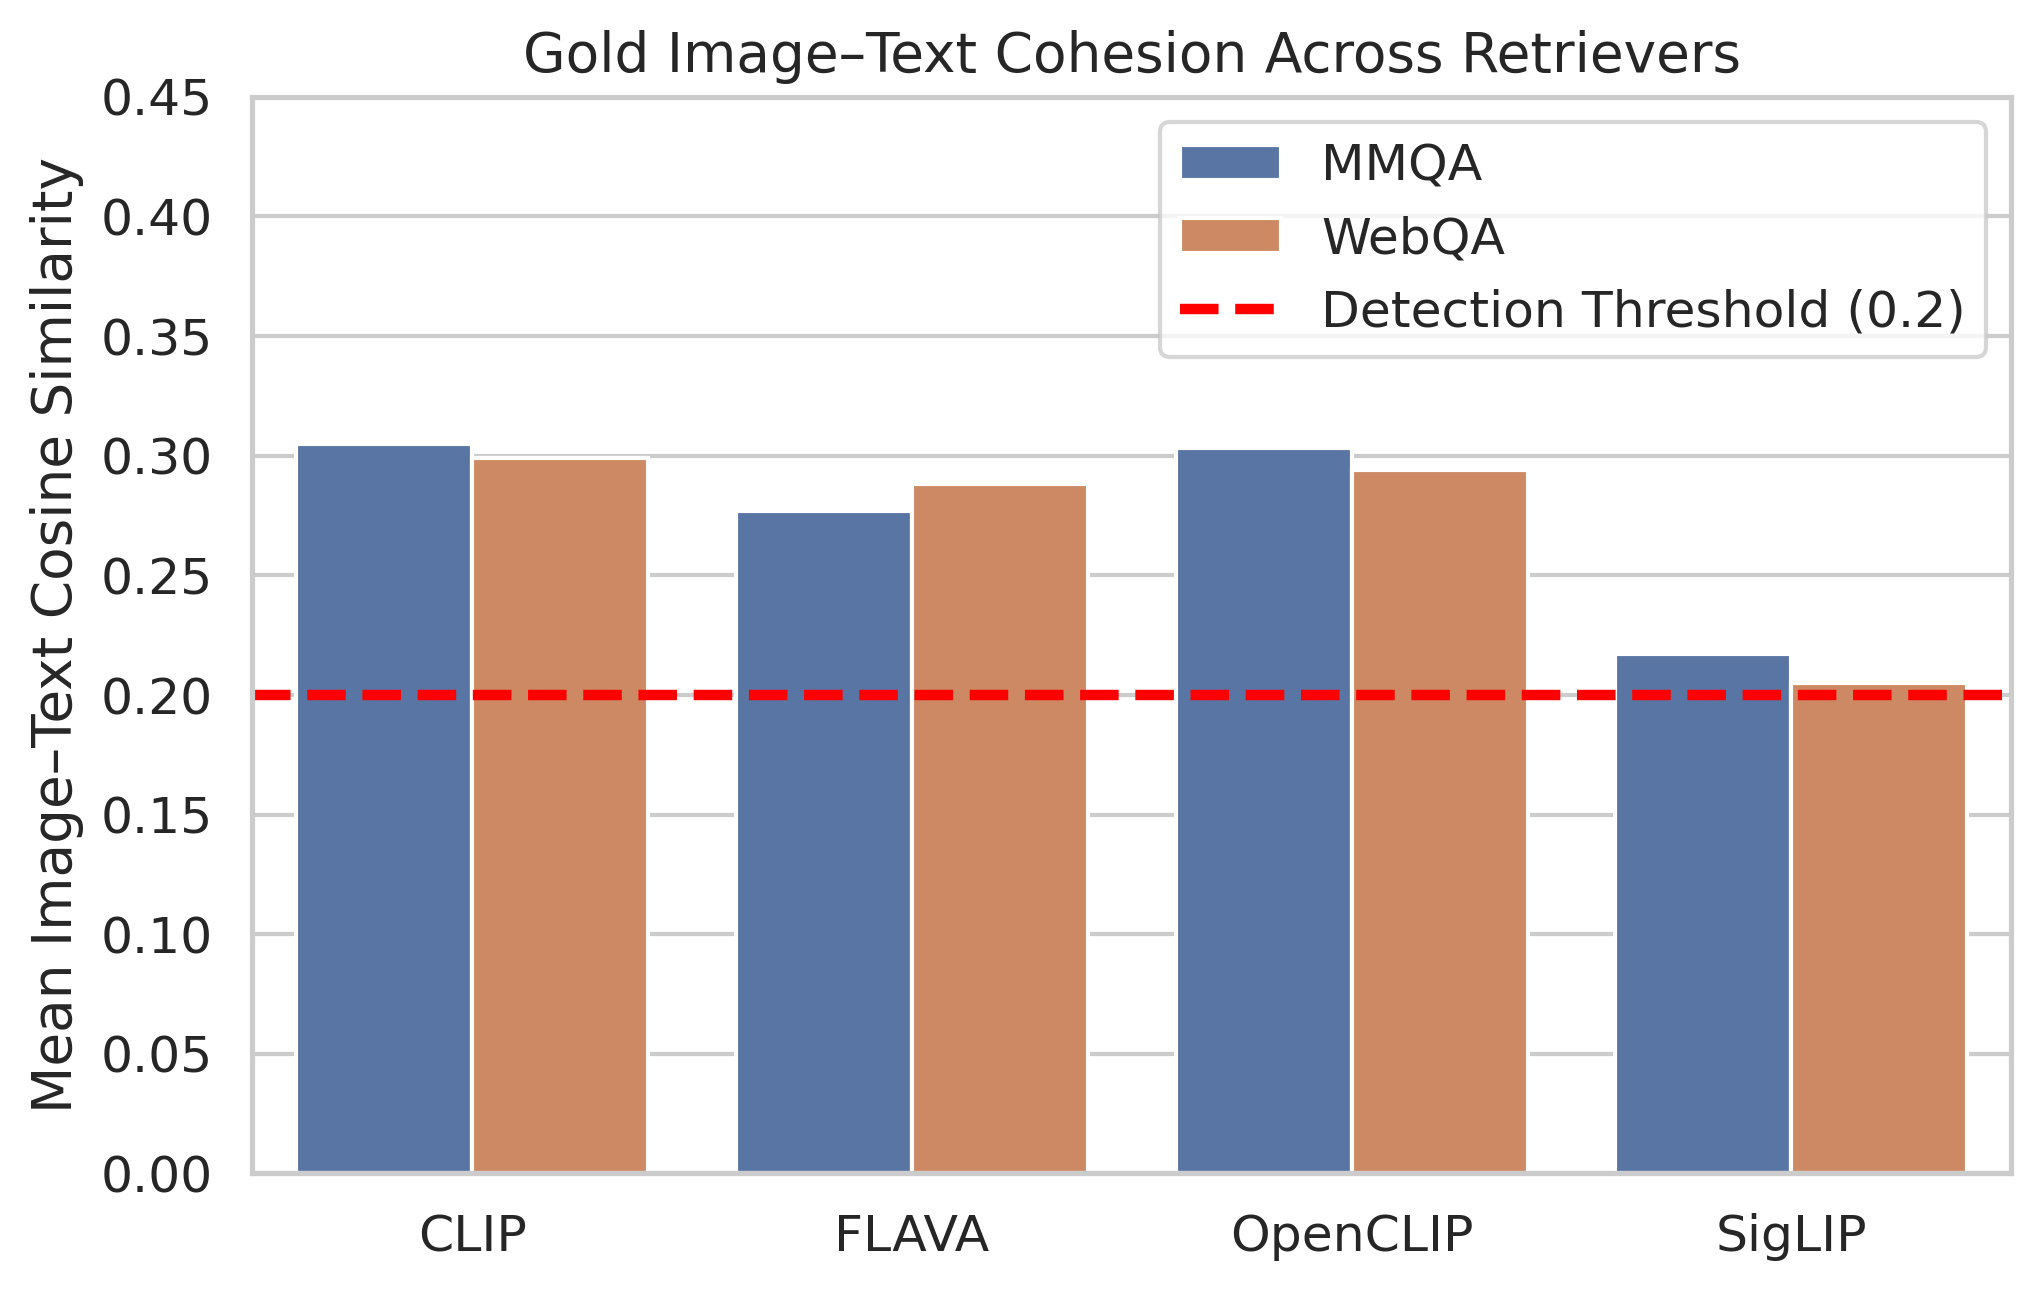

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


data = pd.DataFrame({
    "Retriever": ["CLIP", "FLAVA", "OpenCLIP", "SigLIP"] * 2,
    "Dataset": ["MMQA"] * 4 + ["WebQA"] * 4,
    "Cohesion": [
        0.305, 0.277, 0.303, 0.217,  # MMQA
        0.299, 0.288, 0.294, 0.205   # WebQA
    ]
})

threshold = 0.2


sns.set_theme(style="whitegrid", font_scale=1.1)

plt.figure(figsize=(7, 4.5), dpi=300)

palette = ["#4C72B0", "#DD8452"]

ax = sns.barplot(
    data=data,
    x="Retriever",
    y="Cohesion",
    hue="Dataset",
    palette=palette
)

plt.axhline(
    threshold,
    linestyle="--",
    linewidth=2.5,
    color="red",
    label="Detection Threshold (0.2)"
)


plt.ylim(0, 0.45)
plt.ylabel("Mean Image–Text Cosine Similarity")
plt.xlabel("")
plt.title("Gold Image–Text Cohesion Across Retrievers")
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("gold_image_text_cohesion.pdf", format="pdf", bbox_inches="tight")
plt.show()